In [2]:
from google.colab import files

uploaded = files.upload()

Saving MRI_of_Human_Brain.jpg to MRI_of_Human_Brain.jpg
Saving eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium.jpg to eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium (1).jpg


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [6]:
xray = cv2.imread("eXtmE1V2XgsjZK2JolVQ5g_Border_of_left_atrium.jpg")
mri = cv2.imread("MRI_of_Human_Brain.jpg")

xray = cv2.cvtColor(xray, cv2.COLOR_BGR2RGB)
mri = cv2.cvtColor(mri, cv2.COLOR_BGR2RGB)

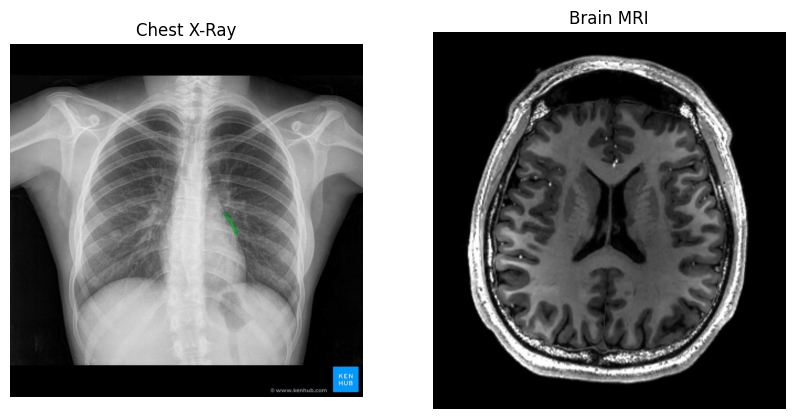

In [7]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(xray)
plt.title("Chest X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mri)
plt.title("Brain MRI")
plt.axis("off")

plt.show()

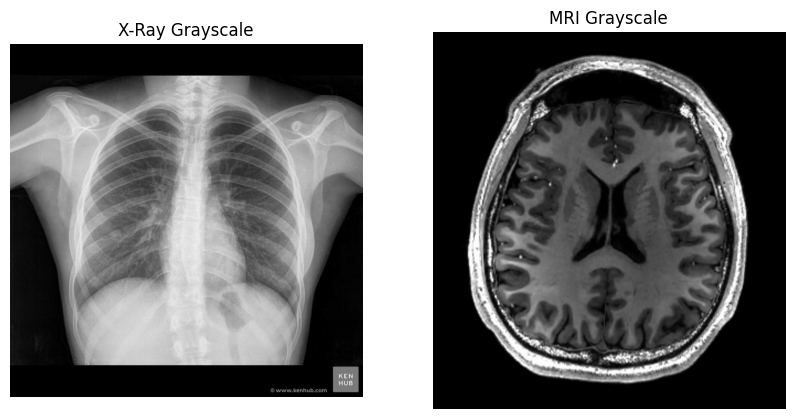

In [8]:
gray_xray = cv2.cvtColor(xray, cv2.COLOR_RGB2GRAY)
gray_mri = cv2.cvtColor(mri, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray_xray, cmap='gray')
plt.title("X-Ray Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray_mri, cmap='gray')
plt.title("MRI Grayscale")
plt.axis("off")

plt.show()

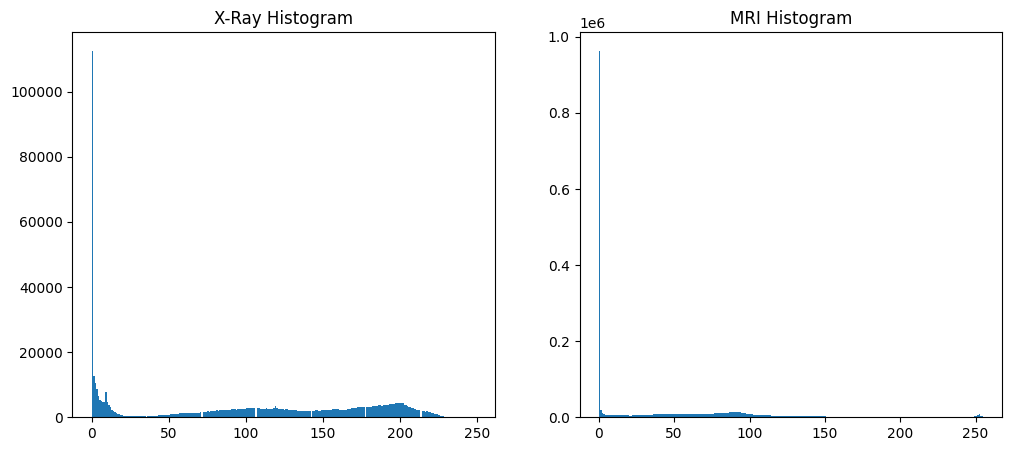

In [9]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(gray_xray.ravel(), bins=256)
plt.title("X-Ray Histogram")

plt.subplot(1,2,2)
plt.hist(gray_mri.ravel(), bins=256)
plt.title("MRI Histogram")

plt.show()

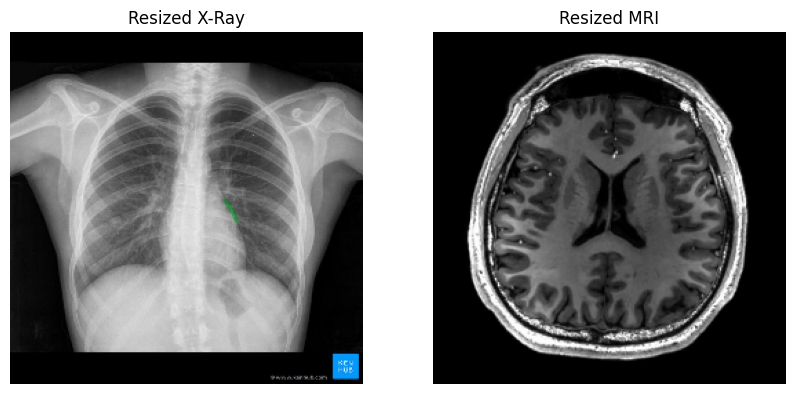

In [10]:
resized_xray = cv2.resize(xray, (256,256))
resized_mri = cv2.resize(mri, (256,256))

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(resized_xray)
plt.title("Resized X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(resized_mri)
plt.title("Resized MRI")
plt.axis("off")

plt.show()

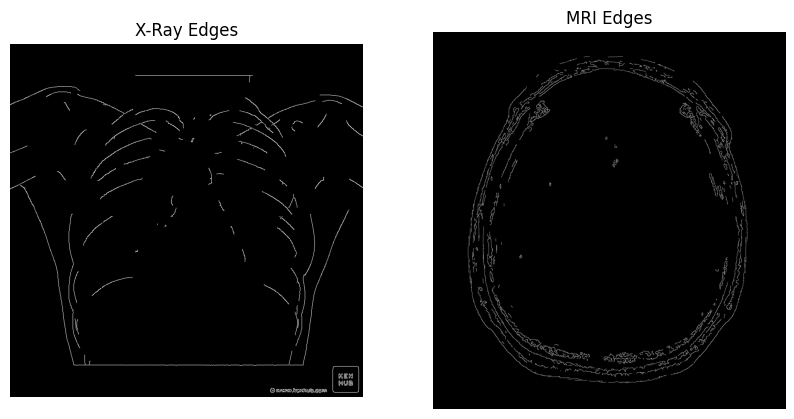

In [11]:
edges_xray = cv2.Canny(gray_xray,100,200)
edges_mri = cv2.Canny(gray_mri,100,200)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(edges_xray,cmap='gray')
plt.title("X-Ray Edges")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges_mri,cmap='gray')
plt.title("MRI Edges")
plt.axis("off")

plt.show()

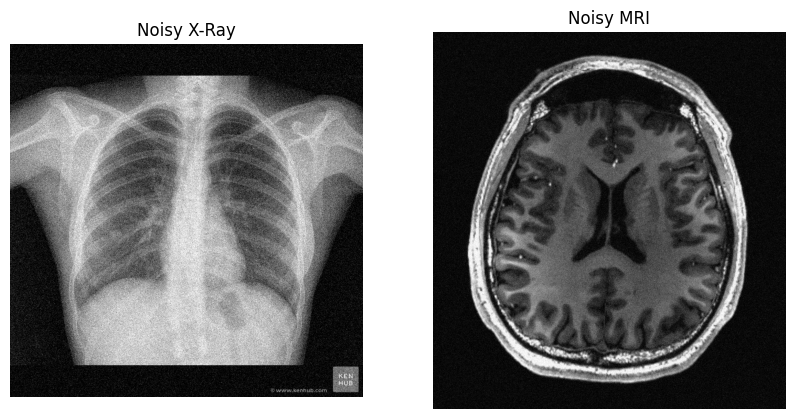

In [12]:
noise_xray = np.random.normal(0,25,gray_xray.shape)
noise_mri = np.random.normal(0,25,gray_mri.shape)

noisy_xray = gray_xray + noise_xray
noisy_mri = gray_mri + noise_mri

noisy_xray = np.clip(noisy_xray,0,255).astype(np.uint8)
noisy_mri = np.clip(noisy_mri,0,255).astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(noisy_xray,cmap='gray')
plt.title("Noisy X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy_mri,cmap='gray')
plt.title("Noisy MRI")
plt.axis("off")

plt.show()

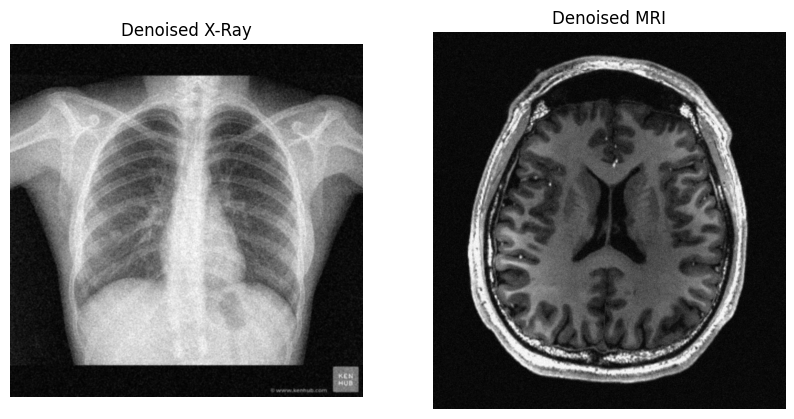

In [13]:
denoised_xray = cv2.GaussianBlur(noisy_xray,(5,5),0)
denoised_mri = cv2.GaussianBlur(noisy_mri,(5,5),0)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(denoised_xray,cmap='gray')
plt.title("Denoised X-Ray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(denoised_mri,cmap='gray')
plt.title("Denoised MRI")
plt.axis("off")

plt.show()